In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import GroupKFold
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style='whitegrid')
import warnings
warnings.filterwarnings('ignore')

In [120]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', None)

In [121]:
df_train = pd.read_csv("data/Train.csv")
df_test = pd.read_csv("data/Test.csv")

In [122]:
feature_list = df_train.columns.tolist()
print(feature_list)

['Place_ID X Date', 'Date', 'Place_ID', 'target', 'target_min', 'target_max', 'target_variance', 'target_count', 'precipitable_water_entire_atmosphere', 'relative_humidity_2m_above_ground', 'specific_humidity_2m_above_ground', 'temperature_2m_above_ground', 'u_component_of_wind_10m_above_ground', 'v_component_of_wind_10m_above_ground', 'L3_NO2_NO2_column_number_density', 'L3_NO2_NO2_slant_column_number_density', 'L3_NO2_absorbing_aerosol_index', 'L3_NO2_cloud_fraction', 'L3_NO2_sensor_altitude', 'L3_NO2_sensor_azimuth_angle', 'L3_NO2_sensor_zenith_angle', 'L3_NO2_solar_azimuth_angle', 'L3_NO2_solar_zenith_angle', 'L3_NO2_stratospheric_NO2_column_number_density', 'L3_NO2_tropopause_pressure', 'L3_NO2_tropospheric_NO2_column_number_density', 'L3_O3_O3_column_number_density', 'L3_O3_O3_effective_temperature', 'L3_O3_cloud_fraction', 'L3_O3_sensor_azimuth_angle', 'L3_O3_sensor_zenith_angle', 'L3_O3_solar_azimuth_angle', 'L3_O3_solar_zenith_angle', 'L3_CO_CO_column_number_density', 'L3_CO_H

In [123]:
#Unique places
train_ids = set(df_train['Place_ID'].unique())
test_ids = set(df_test['Place_ID'].unique())

overlap = train_ids & test_ids

print(f"Train locations: {len(train_ids)}")
print(f"Test locations: {len(test_ids)}")
print(f"Overlap: {len(overlap)}")

Train locations: 340
Test locations: 179
Overlap: 0


In [124]:
df_train.head()

,Place_ID X Date,Date,Place_ID,target,target_min,target_max,target_variance,target_count,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,specific_humidity_2m_above_ground,temperature_2m_above_ground,u_component_of_wind_10m_above_ground,v_component_of_wind_10m_above_ground,L3_NO2_NO2_column_number_density,L3_NO2_NO2_slant_column_number_density,L3_NO2_absorbing_aerosol_index,L3_NO2_cloud_fraction,L3_NO2_sensor_altitude,L3_NO2_sensor_azimuth_angle,L3_NO2_sensor_zenith_angle,L3_NO2_solar_azimuth_angle,L3_NO2_solar_zenith_angle,L3_NO2_stratospheric_NO2_column_number_density,L3_NO2_tropopause_pressure,L3_NO2_tropospheric_NO2_column_number_density,L3_O3_O3_column_number_density,L3_O3_O3_effective_temperature,L3_O3_cloud_fraction,L3_O3_sensor_azimuth_angle,L3_O3_sensor_zenith_angle,L3_O3_solar_azimuth_angle,L3_O3_solar_zenith_angle,L3_CO_CO_column_number_density,L3_CO_H2O_column_number_density,L3_CO_cloud_height,L3_CO_sensor_altitude,L3_CO_sensor_azimuth_angle,L3_CO_sensor_zenith_angle,L3_CO_solar_azimuth_angle,L3_CO_solar_zenith_angle,L3_HCHO_HCHO_slant_column_number_density,L3_HCHO_cloud_fraction,L3_HCHO_sensor_azimuth_angle,L3_HCHO_sensor_zenith_angle,L3_HCHO_solar_azimuth_angle,L3_HCHO_solar_zenith_angle,L3_HCHO_tropospheric_HCHO_column_number_density,L3_HCHO_tropospheric_HCHO_column_number_density_amf,L3_CLOUD_cloud_base_height,L3_CLOUD_cloud_base_pressure,L3_CLOUD_cloud_fraction,L3_CLOUD_cloud_optical_depth,L3_CLOUD_cloud_top_height,L3_CLOUD_cloud_top_pressure,L3_CLOUD_sensor_azimuth_angle,L3_CLOUD_sensor_zenith_angle,L3_CLOUD_solar_azimuth_angle,L3_CLOUD_solar_zenith_angle,L3_CLOUD_surface_albedo,L3_AER_AI_absorbing_aerosol_index,L3_AER_AI_sensor_altitude,L3_AER_AI_sensor_azimuth_angle,L3_AER_AI_sensor_zenith_angle,L3_AER_AI_solar_azimuth_angle,L3_AER_AI_solar_zenith_angle,L3_SO2_SO2_column_number_density,L3_SO2_SO2_column_number_density_amf,L3_SO2_SO2_slant_column_number_density,L3_SO2_absorbing_aerosol_index,L3_SO2_cloud_fraction,L3_SO2_sensor_azimuth_angle,L3_SO2_sensor_zenith_angle,L3_SO2_solar_azimuth_angle,L3_SO2_solar_zenith_angle,L3_CH4_CH4_column_volume_mixing_ratio_dry_air,L3_CH4_aerosol_height,L3_CH4_aerosol_optical_depth,L3_CH4_sensor_azimuth_angle,L3_CH4_sensor_zenith_angle,L3_CH4_solar_azimuth_angle,L3_CH4_solar_zenith_angle
0,010Q650 X 2020-01-02,2020-01-02,010Q650,38.0,23.0,53.0,769.50,92,11.000000,60.200001,0.00804,18.516840,1.996377,-1.227395,0.000074,0.000156,-1.231330,0.006507,840209.874619,76.537512,38.634284,-61.736719,22.358167,0.000057,6156.074219,0.000017,0.119095,234.151102,0.000000,76.536426,38.593017,-61.752587,22.363665,0.021080,883.332451,267.017184,840138.461052,74.543393,38.622451,-61.789016,22.379054,-0.000010,0.000000,76.536426,38.593017,-61.752587,22.363665,0.000064,0.566828,NaN,NaN,0.000000,NaN,NaN,NaN,76.536426,38.593017,-61.752587,22.363665,NaN,-1.231330,840209.874619,76.537512,38.634284,-61.736719,22.358167,-0.000127,0.312521,-0.000040,-1.861476,0.000000,76.536426,38.593017,-61.752587,22.363665,1793.793579,3227.855469,0.010579,74.481049,37.501499,-62.142639,22.545118
1,010Q650 X 2020-01-03,2020-01-03,010Q650,39.0,25.0,63.0,1319.85,91,14.600000,48.799999,0.00839,22.546533,3.330430,-1.188108,0.000076,0.000197,-1.082553,0.018360,840772.941995,-14.708036,59.624912,-67.693509,28.614804,0.000055,6156.074219,0.000021,0.115179,233.313706,0.059433,-14.708036,59.624912,-67.693509,28.614804,0.022017,1148.985447,61.216687,841116.763051,-57.015200,61.402626,-74.457583,33.089495,0.000114,0.059433,-14.708036,59.624912,-67.693509,28.614804,0.000171,0.858446,175.019862,99354.162958,0.059358,5.958538,175.072145,99353.672374,-14.708036,59.624912,-67.693509,28.614804,0.315403,-1.082553,840772.941995,-14.708036,59.624912,-67.693509,28.614804,0.000150,0.433957,0.000050,-1.452612,0.059433,-14.708036,59.624912,-67.693509,28.614804,1789.960449,3384.226562,0.015104,75.630043,55.657486,-53.868134,19.293652
2,010Q650 X 2020-01-04,2020-01-04,010Q650,24.0,8.0,56.0,1181.96,96,16.400000,33.400002,0

## Train-Test Split by Location (no overlap)

In [125]:


RANDOM_STATE = 42

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, val_idx = next(gss.split(df_train, groups=df_train['Place_ID']))

val_places = df_train.iloc[val_idx]['Place_ID'].unique()

place_split = df_train[['Place_ID']].drop_duplicates()
place_split['split'] = 'train'
place_split.loc[place_split['Place_ID'].isin(val_places), 'split'] = 'val'

place_split.to_csv('data/shared_place_split.csv', index=False)

In [126]:
place_split = pd.read_csv('data/shared_place_split.csv')
df = df_train.merge(place_split, on='Place_ID')

X_train = df[df.split == 'train'].drop(columns=['target', 'split'])
y_train = df[df.split == 'train']['target']
X_val   = df[df.split == 'val'].drop(columns=['target', 'split'])
y_val   = df[df.split == 'val']['target']

assert set(X_train['Place_ID']) & set(X_val['Place_ID']) == set()  # sanity check

In [127]:
#Unique places
train_ids = set(X_train['Place_ID'].unique())
test_ids = set(X_val['Place_ID'].unique())

overlap = train_ids & test_ids

print(f"Train locations: {len(train_ids)}")
print(f"Test locations: {len(test_ids)}")
print(f"Overlap: {len(overlap)}")

Train locations: 272
Test locations: 68
Overlap: 0


## EDA - Satellite Data

In [128]:
# Separate Satellite Data from Train Data
sat_cols = [c for c in df_train.columns if c.startswith("L3_")]
base_cols = ["Place_ID", "Date"]

df_sat = df_train[base_cols + sat_cols + ["target"]].copy()
df_base = df_train[base_cols].copy()

print(df_sat.shape)

(30557, 71)


#### Drop Angle Coloumns

In [129]:
angle_cols = [c for c in df_train.columns if c.endswith("_angle")]
df_sat = df_sat.drop(columns=angle_cols) 

#### Create Dictionary for Feature groups

In [130]:
FEATURE_GROUPS = {
    "ground_sensor": ["target_min", "target_max", "target_variance", "target_count"],  # target selbst separat halten
    "weather": [
        "precipitable_water_entire_atmosphere", "relative_humidity_2m_above_ground",
        "specific_humidity_2m_above_ground", "temperature_2m_above_ground",
        "u_component_of_wind_10m_above_ground", "v_component_of_wind_10m_above_ground",
    ],
    "satellite": {
        "NO2": [c for c in df_sat.columns if c.startswith("L3_NO2_")],
        "O3": [c for c in df_sat.columns if c.startswith("L3_O3_")],
        "CO": [c for c in df_sat.columns if c.startswith("L3_CO_")],
        "HCHO": [c for c in df_sat.columns if c.startswith("L3_HCHO_")],
        "CLOUD": [c for c in df_sat.columns if c.startswith("L3_CLOUD_")],
        "AER_AI": [c for c in df_sat.columns if c.startswith("L3_AER_AI_")],
        "SO2": [c for c in df_sat.columns if c.startswith("L3_SO2_")],
        "CH4": [c for c in df_sat.columns if c.startswith("L3_CH4_")],
    },
}

### Missing Data Handling

In [131]:
df_sat.isna().mean().sort_values(ascending=False)  # Missingness-Überblick pro Spalte


L3_CH4_CH4_column_volume_mixing_ratio_dry_air          0.810453
L3_CH4_aerosol_optical_depth                           0.810453
L3_CH4_aerosol_height                                  0.810453
L3_NO2_tropospheric_NO2_column_number_density          0.283699
L3_HCHO_tropospheric_HCHO_column_number_density_amf    0.242989
L3_HCHO_HCHO_slant_column_number_density               0.242989
L3_HCHO_tropospheric_HCHO_column_number_density        0.242989
L3_HCHO_cloud_fraction                                 0.242989
L3_SO2_absorbing_aerosol_index                         0.239160
L3_SO2_cloud_fraction                                  0.236836
L3_SO2_SO2_slant_column_number_density                 0.236836
L3_SO2_SO2_column_number_density_amf                   0.236836
L3_SO2_SO2_column_number_density                       0.236836
L3_CO_CO_column_number_density                         0.177472
L3_CO_H2O_column_number_density                        0.177472
L3_CO_cloud_height                      

In [132]:
# Check if Missing values are in the same rows for each pollutant subgroup
ch4_cols = FEATURE_GROUPS["satellite"]["CH4"]
df_sat[ch4_cols].isna().corr()

,L3_CH4_CH4_column_volume_mixing_ratio_dry_air,L3_CH4_aerosol_height,L3_CH4_aerosol_optical_depth
L3_CH4_CH4_column_volume_mixing_ratio_dry_air,1.0,1.0,1.0
L3_CH4_aerosol_height,1.0,1.0,1.0
L3_CH4_aerosol_optical_depth,1.0,1.0,1.0


Result: Yes, missing values inside a pollutant subgroup are highly to fully correlated

### Subgroup analysis

Creating a table to see for each feature inside its group:
- percentage of missing data (NAN)
- percetage of zero values
- min and max
- NAN-Correlation inside its group. If ~1 NANs are in the same row

In [133]:
def diagnose_group(df, cols, group_name):
    summary = pd.DataFrame({
        "pct_missing": df[cols].isna().mean(),
        "pct_zero": (df[cols] == 0).mean(),
        "min": df[cols].min(),
        "max": df[cols].max(),
    })
    nan_corr = df[cols].isna().corr()
    print(f"--- {group_name} ---")
    print(summary.round(7).to_string())
    print("\nNaN-Korrelation innerhalb der Gruppe (sollte ~1 sein, falls Pass-basiert):")
    print(nan_corr.round(2).to_string())
    print()
    return summary



In [134]:
for product, cols in FEATURE_GROUPS["satellite"].items():
    # if product == "CH4":
    #    continue  # schon erledigt
    diagnose_group(df_sat, cols, product)

--- NO2 ---
                                                pct_missing  pct_zero       min            max
L3_NO2_NO2_column_number_density                   0.071637  0.085447 -0.000051       0.002998
L3_NO2_NO2_slant_column_number_density             0.071637  0.085447  0.000000       0.002431
L3_NO2_absorbing_aerosol_index                     0.071637  0.085447 -3.941742       4.824802
L3_NO2_cloud_fraction                              0.071637  0.094806  0.000000       1.000000
L3_NO2_sensor_altitude                             0.071637  0.085447  0.000000  844493.897695
L3_NO2_stratospheric_NO2_column_number_density     0.071669  0.085447  0.000000       0.000069
L3_NO2_tropopause_pressure                         0.071669  0.085447  0.000000   31592.342847
L3_NO2_tropospheric_NO2_column_number_density      0.283699  0.085447 -0.000048       0.002054

NaN-Korrelation innerhalb der Gruppe (sollte ~1 sein, falls Pass-basiert):
                                                L3_NO2_NO

### Key Findings in table

NO2:
- Structural NAN-values ~7%
- Structural invalid 0-values ~8.5% -> Can be transformed to NAN.
- Outlier behaviour of L3_NO2_tropospheric_NO2_column_number_density. Must be treated separately
- Nan-values + 0-values ~16% -> Creation feature is_measured-flag

CH4:
- Structural NAN-values ~81%
- Structural invalid 0-values ~9.5% -> Can be transformed to NAN.
- Nan-values + 0-values ~90% -> Creation feature is_measured-flag

O3:     Low number of mission values -> No action

CO:     Structural NAN-values ~18% -> -> Creation feature is_measured-flag

CO:     Structural NAN-values ~24% -> -> Creation feature is_measured-flag

HCHO:   Low number of mission values -> No action

AER_AI: Low number of mission values -> No action

SO2:    Structural NAN-values ~24% -> -> Creation feature is_measured-flag


### Applying Actions

#### NO2

In [135]:
# ---- NO2 ---- 
# Slant/Total-Messung vs. troposphärische Modell-Ableitung getrennt
no2_core_cols = ["L3_NO2_NO2_column_number_density", "L3_NO2_NO2_slant_column_number_density",
                  "L3_NO2_stratospheric_NO2_column_number_density"]
df_sat["no2_measured"] = df_sat[no2_core_cols[0]].notna().astype(int)
df_sat["no2_tropospheric_derived"] = df_sat["L3_NO2_tropospheric_NO2_column_number_density"].notna().astype(int)

In [136]:
no2_cols = FEATURE_GROUPS["satellite"]["NO2"]

# Schritt 1: Verifizieren, wie viele 0en es tatsächlich gibt und ob sie 
# wirklich "exakt 0" sind oder nur sehr klein (Rundungsfehler vs. echter Fill-Value)
(df_sat[no2_cols[0]] == 0).sum(), df_sat[no2_cols[0]].between(0, 50).sum()



(2611, 28342)

In [137]:
# Schritt 2: 0 als ungültig behandeln -> zu NaN konvertieren
for col in no2_cols:
    df_sat[col] = df_sat[col].replace(0, np.nan)

# Schritt 3: Flag NACH der 0->NaN Konvertierung neu berechnen 
# (überschreibt deinen vorherigen Flag, der nur "echte" NaNs erfasst hat)
df_sat["no2_measured"] = df_sat[no2_cols[0]].notna().astype(int)

#### CO4

In [138]:
ch4_cols = FEATURE_GROUPS["satellite"]["CH4"]

# Schritt 1: Verifizieren, wie viele 0en es tatsächlich gibt und ob sie 
# wirklich "exakt 0" sind oder nur sehr klein (Rundungsfehler vs. echter Fill-Value)
(df_sat[ch4_cols[0]] == 0).sum(), df_sat[ch4_cols[0]].between(0, 50).sum()

# Schritt 2: 0 als ungültig behandeln -> zu NaN konvertieren
for col in ch4_cols:
    df_sat[col] = df_sat[col].replace(0, np.nan)

# Schritt 3: Flag NACH der 0->NaN Konvertierung neu berechnen 
# (überschreibt deinen vorherigen Flag, der nur "echte" NaNs erfasst hat)
df_sat["ch4_measured"] = df_sat[ch4_cols[0]].notna().astype(int)

#### CO - HCHO - SO2

In [139]:
for group, flag_name in [("NO2", "no2_measured"),("CO", "co_measured"), ("HCHO", "hcho_measured"), ("SO2", "so2_measured")]:
    cols = FEATURE_GROUPS["satellite"][group]
    df_sat[flag_name] = df_sat[cols[0]].notna().astype(int)
    # cols[0] reicht, da NaN-Korrelation innerhalb dieser Gruppen schon als ~0.99-1.0 bestätigt ist

### Analyse Subgroup Correlations

In [140]:
for group, cols in FEATURE_GROUPS["satellite"].items():
    if len(cols) < 2:
        continue
    corr = df_sat[cols].corr()
    print(f"--- {group} ---")
    print(corr.round(2).to_string())
    print()

--- NO2 ---
                                                L3_NO2_NO2_column_number_density  L3_NO2_NO2_slant_column_number_density  L3_NO2_absorbing_aerosol_index  L3_NO2_cloud_fraction  L3_NO2_sensor_altitude  L3_NO2_stratospheric_NO2_column_number_density  L3_NO2_tropopause_pressure  L3_NO2_tropospheric_NO2_column_number_density
L3_NO2_NO2_column_number_density                                            1.00                                    0.79                           -0.00                  -0.11                   -0.08                                            0.03                        0.07                                           0.93
L3_NO2_NO2_slant_column_number_density                                      0.79                                    1.00                            0.07                  -0.23                   -0.02                                            0.12                        0.14                                           0.86
L3_NO2_absorbing_ae

In [141]:
groups_to_resolve = {
    "NO2_core": ["L3_NO2_NO2_column_number_density", "L3_NO2_NO2_slant_column_number_density",
                 "L3_NO2_tropospheric_NO2_column_number_density"],
    "HCHO_core": ["L3_HCHO_HCHO_slant_column_number_density", "L3_HCHO_tropospheric_HCHO_column_number_density"],
}

for name, cols in groups_to_resolve.items():
    tc = X_train[cols].corrwith(y_train).abs()  # NUR train_internal
    print(f"{name}:\n{tc.round(3)}\n")

NO2_core:
L3_NO2_NO2_column_number_density                 0.334
L3_NO2_NO2_slant_column_number_density           0.349
L3_NO2_tropospheric_NO2_column_number_density    0.329
dtype: float64

HCHO_core:
L3_HCHO_HCHO_slant_column_number_density           0.314
L3_HCHO_tropospheric_HCHO_column_number_density    0.347
dtype: float64



In [142]:
flag_cols = ["ch4_measured", "no2_measured", "no2_tropospheric_derived", 
             "co_measured", "hcho_measured", "so2_measured"]

df_sat[flag_cols].corr().round(2)

,ch4_measured,no2_measured,no2_tropospheric_derived,co_measured,hcho_measured,so2_measured
ch4_measured,1.00,0.06,0.20,0.15,0.17,0.16
no2_measured,0.06,1.00,0.17,0.36,0.32,0.35
no2_tropospheric_derived,0.20,0.17,1.00,0.44,0.68,0.64
co_measured,0.15,0.36,0.44,1.00,0.50,0.50
hcho_measured,0.17,0.32,0.68,0.50,1.00,0.91
so2_measured,0.16,0.35,0.64,0.50,0.91,1.00


In [143]:
drop_redundant = [  "L3_CLOUD_cloud_base_height", 
                    "L3_CLOUD_cloud_base_pressure", 
                    "L3_CLOUD_cloud_top_pressure",    
                    "L3_NO2_NO2_column_number_density",
                    "L3_NO2_NO2_slant_column_number_density",
                    "L3_HCHO_HCHO_slant_column_number_density"]
df_sat = df_sat.drop(columns=drop_redundant)

In [144]:
# df_sat = df_sat.drop(columns='target') 

## EDA - Weather Data

In [145]:
# Evaluation function
def evaluate(name, model):
    model.fit(X_tr, y_train)
    pred = model.predict(X_va)
    rmse = np.sqrt(mean_squared_error(y_val, pred))
    mae  = mean_absolute_error(y_val, pred)
    r2   = r2_score(y_val, pred)
    print(f'{name:22} RMSE={rmse:6.2f}  MAE={mae:6.2f}  R2={r2:6.3f}')
    return model

In [146]:
base_cols = ["Place_ID", "Date"]
weather_cols = [
    'precipitable_water_entire_atmosphere',
    'relative_humidity_2m_above_ground',
    'specific_humidity_2m_above_ground',
    'temperature_2m_above_ground',
    'u_component_of_wind_10m_above_ground',
    'v_component_of_wind_10m_above_ground',
]

df_weather = df_train[base_cols + weather_cols].copy()

In [147]:
# Weather data frame (with targets)
df_weather = pd.concat([df_weather, y_train], axis=1)
df_weather.head()

,Place_ID,Date,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,specific_humidity_2m_above_ground,temperature_2m_above_ground,u_component_of_wind_10m_above_ground,v_component_of_wind_10m_above_ground,target
0,010Q650,2020-01-02,11.000000,60.200001,0.00804,18.516840,1.996377,-1.227395,38.0
1,010Q650,2020-01-03,14.600000,48.799999,0.00839,22.546533,3.330430,-1.188108,39.0
2,010Q650,2020-01-04,16.400000,33.400002,0.00750,27.031030,5.065727,3.500559,24.0
3,010Q650,2020-01-05,6.911948,21.300001,0.00391,23.971857,3.004001,1.099468,49.0
4,010Q650,2020-01-06,13.900001,44.700001,0.00535,16.816309,2.621787,2.670559,21.0


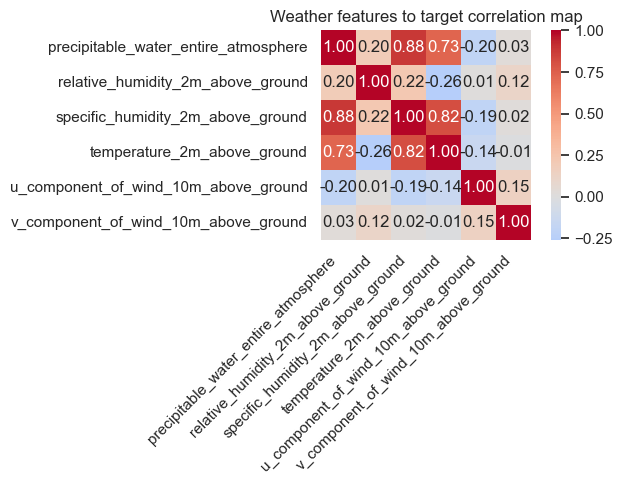

In [148]:
# Correlation heat map
plt.figure(figsize=(7, 5))
sns.heatmap(df_weather[weather_cols].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Weather features to target correlation map')
plt.xticks(rotation=45, ha='right')  
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [149]:
# Removing specific humidity, due to high correlation with precipitable_water_entire_atmosphere (included in it)
df_weather= df_weather.drop(columns='specific_humidity_2m_above_ground')
df_weather.columns

Index(['Place_ID', 'Date', 'precipitable_water_entire_atmosphere',
       'relative_humidity_2m_above_ground', 'temperature_2m_above_ground',
       'u_component_of_wind_10m_above_ground',
       'v_component_of_wind_10m_above_ground', 'target'],
      dtype='object')

In [150]:
# Feature engineering of wind
u = df_weather['u_component_of_wind_10m_above_ground']
v = df_weather['v_component_of_wind_10m_above_ground']

# Calculating wind speed and direction (angle)
df_weather['wind_speed']     = np.sqrt(u**2 + v**2)
df_weather['wind_direction'] = (np.degrees(np.arctan2(v, u)) + 360) % 360   # 0–360°
rad = np.radians(df_weather['wind_direction'])
df_weather['wind_dir_sin'] = np.sin(rad)
df_weather['wind_dir_cos'] = np.cos(rad)
# Why sin and cos: Wind direction is circular (0° = 360°), so we encode it as sin and cos 
# to remove the false jump at the wrap-around and let the model see that directions like 359° 
# and 1° are actually close.

place_split = pd.read_csv('data/shared_place_split.csv')
df_weather = df_weather.merge(place_split, on='Place_ID')

# Schritt 3: Target NUR für die Train-Zeilen für die Korrelations-Diagnose nutzen
df_weather_train = df_weather[df_weather.split == 'train'].merge(
    df_train[['Place_ID', 'Date', 'target']], on=['Place_ID', 'Date']
)

# Wind speed and target corelation:
# sns.regplot(x='wind_speed', y='target', data=df_weather, lowess=True, scatter_kws={'alpha':0.1})

In [151]:
# df_weather = df_weather.drop(columns='target') 
df_weather = df_weather.drop(columns='split') 

In [152]:
df_weather.head()

,Place_ID,Date,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,temperature_2m_above_ground,u_component_of_wind_10m_above_ground,v_component_of_wind_10m_above_ground,target,wind_speed,wind_direction,wind_dir_sin,wind_dir_cos
0,010Q650,2020-01-02,11.000000,60.200001,18.516840,1.996377,-1.227395,38.0,2.343506,328.416332,-0.523743,0.851876
1,010Q650,2020-01-03,14.600000,48.799999,22.546533,3.330430,-1.188108,39.0,3.536009,340.366491,-0.336002,0.941861
2,010Q650,2020-01-04,16.400000,33.400002,27.031030,5.065727,3.500559,24.0,6.157557,34.645557,0.568498,0.822685
3,010Q650,2020-01-05,6.911948,21.300001,23.971857,3.004001,1.099468,49.0,3.198883,20.102680,0.343704,0.939078
4,010Q650,2020-01-06,13.900001,44.700001,16.816309,2.621787,2.670559,21.0,3.742413,45.527997,0.713593,0.700561


In [153]:
df_base.head()

,Place_ID,Date
0,010Q650,2020-01-02
1,010Q650,2020-01-03
2,010Q650,2020-01-04
3,010Q650,2020-01-05
4,010Q650,2020-01-06


## Base Data Analysis

In [154]:
print("Train:", df_train['Date'].min(), "-", df_train['Date'].max())
print("Test: ", df_test['Date'].min(), "-", df_test['Date'].max())

Train: 2020-01-02 - 2020-04-04
Test:  2020-01-02 - 2020-04-04


In [155]:
df_base['Date'] = pd.to_datetime(df_base['Date'])
df_base['weekday'] = df_base['Date'].dt.dayofweek  # 0=Montag, 6=Sonntag
df_base.head()

,Place_ID,Date,weekday
0,010Q650,2020-01-02,3
1,010Q650,2020-01-03,4
2,010Q650,2020-01-04,5
3,010Q650,2020-01-05,6
4,010Q650,2020-01-06,0


## Fusing Data Frames Weather-Satellite

In [156]:
# Simple concat if indeces have not changed.
df_weather_features = df_weather.drop(columns=["target"], errors="ignore")
df_combined = df_sat.merge(df_weather_features, on=["Place_ID", "Date"], how="inner", validate="1:1")


In [157]:
assert len(df_weather) == len(df_sat) == len(df_weather), "Zeilen gehen beim Merge verloren!"

In [158]:
# If error: pip install pyarrow
df_combined.to_parquet("data/df_combined.parquet", index=False)

# Modelling

## Baseline Model - Dummy Model

In [159]:
dummy = DummyRegressor(strategy="mean")
dummy.fit(np.zeros((len(y_train), 1)), y_train)  # Features irrelevant, Dummy ignoriert X komplett
y_pred = dummy.predict(np.zeros((len(y_val), 1)))

baseline_rmse = mean_squared_error(y_val, y_pred, squared=False)
print(f"Baseline RMSE: {baseline_rmse:.2f}")

Baseline RMSE: 42.12
